In [21]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table, unique, join, vstack
import h5py
import glob
import os

In [10]:
def plot_rv_numbers(filename):
    with fits.open(filename) as hdul:
        data = hdul[1].data

    ids = data["GAIAEDR3_ID"]
    rv = data["vrad"]

    print(type(rv))
    print(np.nanmin(rv), np.nanmax(rv))
    print(np.where(np.isfinite(rv) == False)[0])
    print("Done Prof Douglas's prints")

    counts = {}
    has_any_rv = {}
    first_index = {}

    for i, star_id in enumerate(ids):
        if star_id not in first_index:
            first_index[star_id] = i
            counts[star_id] = 0
            has_any_rv[star_id] = False

        if np.isfinite(rv[i]):
            counts[star_id] += 1
            has_any_rv[star_id] = True

    unique_idx = np.array(list(first_index.values()))
    unique_data = data[unique_idx]

    unique_ids = unique_data["GAIAEDR3_ID"]
    bp_rp = unique_data["GAIAEDR3_BP"] - unique_data["GAIAEDR3_RP"]
    G = unique_data["GAIAEDR3_G"]
    dist = unique_data["dist"]
    MG = G - 5 * np.log10(dist) + 5
    mem = unique_data["MemBool"] == 1

    rv_counts = np.array([counts[s] for s in unique_ids])
    has_rv_flag = np.array([has_any_rv[s] for s in unique_ids])

    has_rv = mem & has_rv_flag
    no_rv = mem & ~has_rv_flag

    plt.figure(figsize=(8, 6))

    order = np.argsort(rv_counts[has_rv])

    sc = plt.scatter(
        bp_rp[has_rv][order],
        MG[has_rv][order],
        c=rv_counts[has_rv][order],
        cmap='viridis',
        s=16,
        edgecolors='none'
    )

    plt.colorbar(sc, label="Number of RV data points")
    plt.xlabel("BP - RP")
    plt.ylabel("M_G")
    plt.gca().invert_yaxis()
    plt.title("M_G vs BP-RP")
    plt.show()

    has_rv = np.isfinite(data["vrad"])
    no_rv = ~has_rv
    full_mem = data["MemBool"] == 1


<class 'numpy.ndarray'>
-242.82433 255.80125
[  27   45  170  197  223  290  419  503  628  670  671  801  835  936
  989 1027 1179 1282 1330 1379 1406 1704 1814 1858 1926 2009 2056 2132
 2145 2147 2268 2303 2394 2429 2443 2542 2676 2735 2742 2874 2888 2896
 2926 2984 3138 3144 3166 3304 3379 3405 3701 3748 3782 3857 3927 3932
 3934 3965 3969 4007 4066 4089 4129 4130 4169 4179 4180 4193 4312 4324
 4359 4433 4450 4459 4466 4475 4485 4497 4506 4510 4535 4551 4677 4750
 4751 4760 4768 4785 4801 4842 4848 4936 4937 4946 4954 4971 4987 5028
 5034 5122 5123 5132 5140 5157 5173 5214 5220 5304 5307 5318 5324 5356
 5397 5438]
Done Prof Douglas's prints


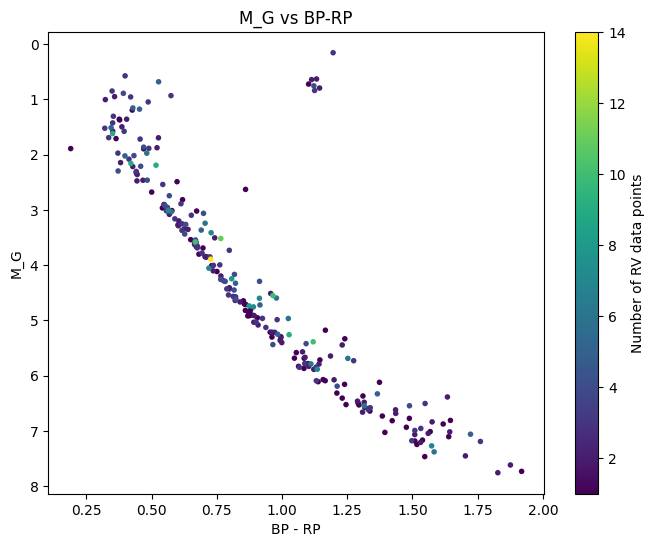

In [11]:
plot_rv_numbers("rcat_ngc6811_v0.fits")

In [12]:
def plot_rv_numbers_table(filename):
    with fits.open(filename) as hdul:
        data = hdul[1].data

    print(type(data["vrad"]))
    print(np.nanmin(data["vrad"]), np.nanmax(data["vrad"]))
    print(np.where(~np.isfinite(data["vrad"]))[0])
    print("Done Prof Douglas's prints")

    from astropy.table import Table
    data = Table(data)

    data["has_rv"] = np.isfinite(data["vrad"]).astype(int)

    grouped = data.group_by("GAIAEDR3_ID")

    first_rows = grouped.groups.aggregate(lambda x: x[0])
    rv_counts_table = grouped.groups.aggregate(np.sum)
    rv_counts = rv_counts_table["has_rv"]

    unique_ids = first_rows["GAIAEDR3_ID"]
    bp_rp = first_rows["GAIAEDR3_BP"] - first_rows["GAIAEDR3_RP"]
    G = first_rows["GAIAEDR3_G"]
    dist = first_rows["dist"]
    MG = G - 5 * np.log10(dist) + 5
    mem = first_rows["MemBool"] == 1

    has_rv = mem & (rv_counts > 0)
    no_rv = mem & (rv_counts == 0)

    plt.figure(figsize=(8, 6))

    order = np.argsort(rv_counts[has_rv])

    sc = plt.scatter(
        bp_rp[has_rv][order],
        MG[has_rv][order],
        c=rv_counts[has_rv][order],
        cmap="viridis",
        s=16,
        edgecolors="none"
    )

    plt.colorbar(sc, label="Number of RV data points")
    plt.xlabel("BP - RP")
    plt.ylabel("M_G")
    plt.gca().invert_yaxis()
    plt.title("M_G vs BP-RP")
    plt.show()

    row_has_rv = np.isfinite(data["vrad"])
    row_no_rv = ~row_has_rv
    full_mem = data["MemBool"] == 1

    print(np.where(row_no_rv & full_mem)[0])
    print(f"Members: {np.sum(mem)}")
    print(f"Non-members: {np.sum(~mem)}")

<class 'numpy.ndarray'>
-242.82433 255.80125
[  27   45  170  197  223  290  419  503  628  670  671  801  835  936
  989 1027 1179 1282 1330 1379 1406 1704 1814 1858 1926 2009 2056 2132
 2145 2147 2268 2303 2394 2429 2443 2542 2676 2735 2742 2874 2888 2896
 2926 2984 3138 3144 3166 3304 3379 3405 3701 3748 3782 3857 3927 3932
 3934 3965 3969 4007 4066 4089 4129 4130 4169 4179 4180 4193 4312 4324
 4359 4433 4450 4459 4466 4475 4485 4497 4506 4510 4535 4551 4677 4750
 4751 4760 4768 4785 4801 4842 4848 4936 4937 4946 4954 4971 4987 5028
 5034 5122 5123 5132 5140 5157 5173 5214 5220 5304 5307 5318 5324 5356
 5397 5438]
Done Prof Douglas's prints


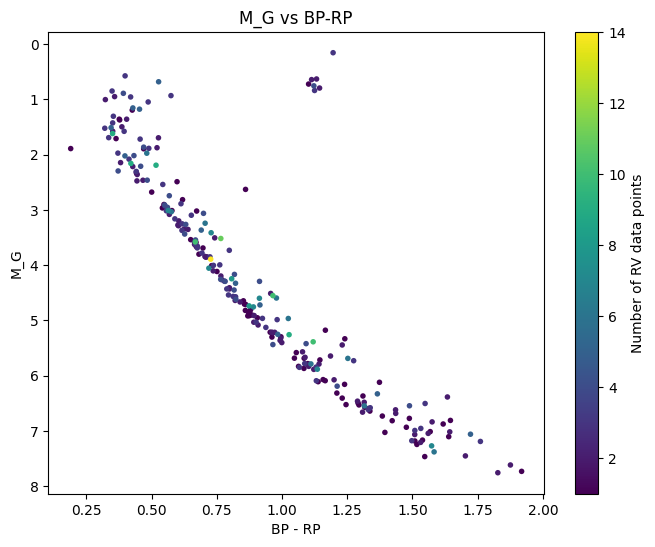

[]
Members: 260
Non-members: 2456


In [13]:
plot_rv_numbers_table("rcat_ngc6811_v0.fits")

In [1]:
def M_g_BPRP_h5(h5_path):

    # Opens h5 file and reads in "catalog" as an array, then closes the file
    with h5py.File(h5_path, "r") as f:
        cat = f["catalog"][:]

    # Extracts wanted individual columns
    G   = cat["GAIAEDR3_G"]
    BP  = cat["GAIAEDR3_BP"]
    RP  = cat["GAIAEDR3_RP"]
    plx = cat["GAIAEDR3_PARALLAX"]
    mem = cat["MemBool"] == 1

    # Only keeps stars with positive parallax, calculates color index BP-RP, computes distance
    mask  = (plx > 0) & mem
    BP_RP = (BP - RP)[mask]
    M_G   = G[mask] + 5 * np.log10(plx[mask] / 1000.0) + 5

    # Plot figure 
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(BP_RP, M_G, s=5, alpha=0.5, color="steelblue", rasterized=True)
    ax.invert_yaxis()
    ax.set_xlabel("BP − RP", fontsize=13)
    ax.set_ylabel("$M_G$", fontsize=13)
    ax.set_title("$M_G$ vs. BP-RP", fontsize=14)
    plt.tight_layout()
    plt.show()

    return fig, ax


def M_g_BPRP_h5_rv_counts(h5_path, fits_path):

    # Opens h5 file and reads in "catalog" as an array, then closes the file
    with h5py.File(h5_path, "r") as f:
        cat = f["catalog"][:]

    # Converts wanted columns into an astropy table for joining later
    h5_table = Table(cat[["GAIAEDR3_ID", "GAIAEDR3_G", "GAIAEDR3_BP",
                           "GAIAEDR3_RP", "GAIAEDR3_PARALLAX", "MemBool"]])

    # Load the fits and only keep the necessary columns
    fits_table = Table.read(fits_path)
    fits_rv = fits_table["GAIAEDR3_ID", "vrad", "vrad_err", "dist", "DATE-OBS"]

    # Left join on the Gaia IDs, every star from the h5 catalog is kept, and the radial velocity data from the fits file is attached. 
    joined = join(h5_table, fits_rv, keys="GAIAEDR3_ID", join_type="left")

    # Loops through all the unique stars, stars can appear multiple times from multiple RV observations, this only counts the non-masked and finite RV measurements per star
    unique_ids = np.unique(joined["GAIAEDR3_ID"])
    counts = {}
    for sid in unique_ids:
        rows = joined[joined["GAIAEDR3_ID"] == sid]
        if hasattr(rows["vrad"], "mask"):
            counts[sid] = int(np.sum(~rows["vrad"].mask))
        else:
            counts[sid] = int(np.sum(np.isfinite(rows["vrad"])))

    # Extracts the index of the first appearance of each unique Gaia ID in the joined table, then creates another table 
    _, first_idx = np.unique(joined["GAIAEDR3_ID"], return_index=True)
    unique_rows = joined[first_idx]

    # Take wanted columns
    G        = np.array(unique_rows["GAIAEDR3_G"])
    BP       = np.array(unique_rows["GAIAEDR3_BP"])
    RP       = np.array(unique_rows["GAIAEDR3_RP"])
    dist     = np.array(unique_rows["dist"])
    mem      = np.array(unique_rows["MemBool"]) == 1
    ids      = np.array(unique_rows["GAIAEDR3_ID"])

    # Computes BP-RP and Mg, builds an array of RV counts, and creates a mask for stars that have at least 1 RV measurement
    BP_RP     = BP - RP
    M_G       = G - 5 * np.log10(dist) + 5
    rv_counts = np.array([counts[s] for s in ids])
    has_rv    = rv_counts > 0

    # Plot 
 
    fig, ax = plt.subplots(figsize=(7.25, 6))
    
    ax.scatter(BP_RP[mem & ~has_rv], M_G[mem & ~has_rv],
               color="lightgrey", s=16, edgecolors="none", label="No RV")

    order = np.argsort(rv_counts[mem & has_rv])
    sc = ax.scatter(
        BP_RP[mem & has_rv][order],
        M_G[mem & has_rv][order],
        c=rv_counts[mem & has_rv][order],
        cmap="viridis",
        s=16,
        edgecolors="none"
    )

    plt.colorbar(sc, ax=ax, label="Number of RV observations")
    ax.invert_yaxis()
    ax.set_xlabel("BP − RP")
    ax.set_ylabel("$M_G$")
    ax.set_title("$M_G$ vs BP-RP")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Determine what stars had a match in the fits file. If the column is a masked array, then it checks whether the mask is false. Otherwise, it checks for finite values
    if hasattr(joined["vrad"], "mask"):
        in_fits = ~joined["vrad"].mask[first_idx]
    else:
        in_fits = np.isfinite(joined["vrad"][first_idx])
    
    not_in_fits = ~in_fits

    # Prints how many stars in each dataset, which gaia IDs are missing from fits, and membership in both files
    print(f"Stars in h5 but not in fits: {np.sum(not_in_fits)}")
    print(f"Stars in h5 and in fits:     {np.sum(in_fits)}")
    print(f"Total unique h5 stars:       {len(unique_rows)}")
    
    print("Gaia IDs not in fits:")
    print(unique_rows["GAIAEDR3_ID"][not_in_fits])

    mem = np.array(unique_rows["MemBool"]) == 1
    print(f"Members in h5:                {np.sum(mem)}")
    print(f"Members in h5 and in fits:    {np.sum(mem & in_fits)}")
    print(f"Members in h5 not in fits:    {np.sum(mem & not_in_fits)}")

    return fig, ax, joined

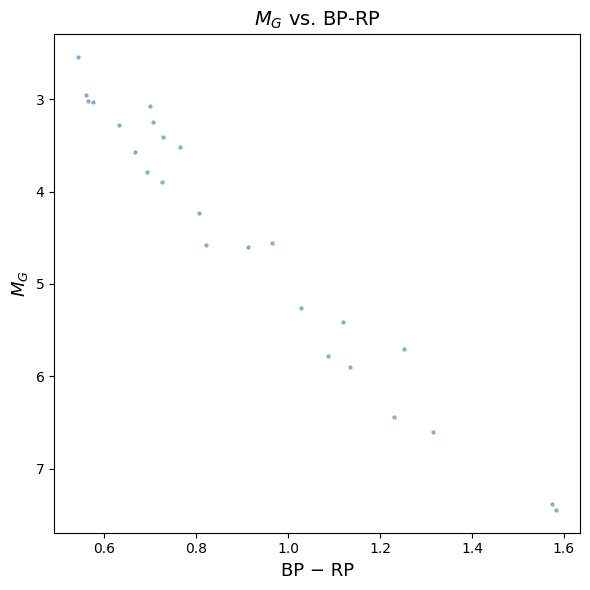

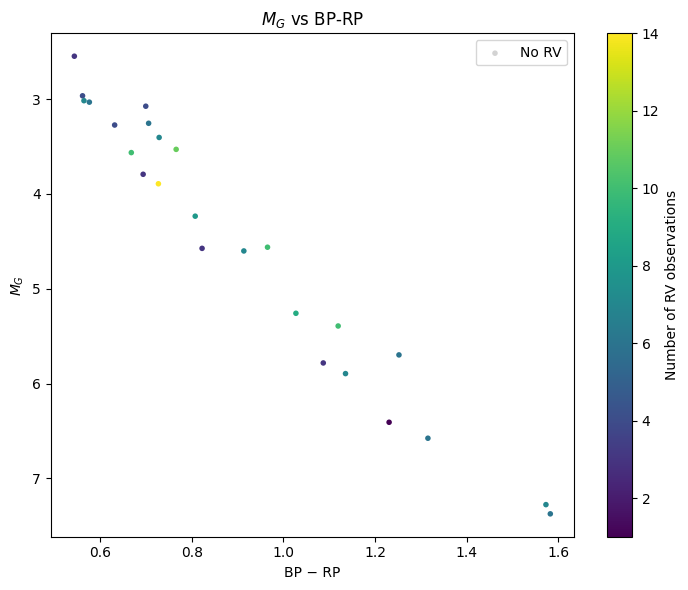

Stars in h5 but not in fits: 7
Stars in h5 and in fits:     175
Total unique h5 stars:       182
Gaia IDs not in fits:
    GAIAEDR3_ID    
-------------------
2080063763947694976
2080090255310324736
2080091492261057408
2128112452142469376
2128132002840746752
2128158154896484480
2128170180806442880
Members in h5:                25
Members in h5 and in fits:    25
Members in h5 not in fits:    0


In [18]:
fig1, ax1 = M_g_BPRP_h5("ngc6811_2019.0624.h5")
fig2, ax2, joined = M_g_BPRP_h5_rv_counts("ngc6811_2019.0624.h5", "rcat_ngc6811_v0.fits")

In [24]:
def M_g_BPRP_h5(script_dir=None, cluster=None):

    if script_dir is None:
        script_dir = os.getcwd()

    h5_files = glob.glob(os.path.join(script_dir, "data", "Reduced Spectra", "*.h5"))

    if not h5_files:
        raise FileNotFoundError("No .h5 files found in Reduced Spectra.")

    # Filter by cluster
    if cluster is not None:
        h5_files = [f for f in h5_files if str(cluster) in os.path.basename(f)]

    if not h5_files:
        raise ValueError(f"No .h5 files found for cluster={cluster}")

    indiv = []
    for h5_path in h5_files:
        with h5py.File(h5_path, "r") as f:
            dat = Table(f["catalog"][:])
        indiv.append(dat)

    cat = vstack(indiv)

    _, first_idx = np.unique(cat["GAIAEDR3_ID"], return_index=True)
    cat = cat[first_idx]

    G   = cat["GAIAEDR3_G"]
    BP  = cat["GAIAEDR3_BP"]
    RP  = cat["GAIAEDR3_RP"]
    plx = cat["GAIAEDR3_PARALLAX"]
    mem = cat["MemBool"] == 1

    mask = (plx > 0) & mem

    BP_RP = (BP - RP)[mask]
    M_G   = G[mask] + 5 * np.log10(plx[mask] / 1000.0) + 5

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(BP_RP, M_G, s=5, alpha=0.5, color="steelblue", rasterized=True)

    ax.invert_yaxis()
    ax.set_xlabel("BP − RP")
    ax.set_ylabel("$M_G$")
    ax.set_title(f"$M_G$ vs BP-RP (cluster={cluster if cluster else 'all'})")

    plt.tight_layout()
    plt.show()

    return fig, ax


def M_g_BPRP_h5_rv_counts(fits_path, script_dir=None, cluster=None):

    if script_dir is None:
        script_dir = os.getcwd()

    h5_files = glob.glob(os.path.join(script_dir, "data", "Reduced Spectra", "*.h5"))

    if cluster is not None:
        h5_files = [f for f in h5_files if str(cluster) in os.path.basename(f)]

    if not h5_files:
        raise ValueError(f"No .h5 files found for cluster={cluster}")

    indiv = []
    for h5_path in h5_files:
        with h5py.File(h5_path, "r") as f:
            dat = Table(f["catalog"][:])
        indiv.append(dat)

    cat = vstack(indiv)

    _, first_idx = np.unique(cat["GAIAEDR3_ID"], return_index=True)
    cat = cat[first_idx]

    h5_table = cat[["GAIAEDR3_ID", "GAIAEDR3_G", "GAIAEDR3_BP",
                "GAIAEDR3_RP", "GAIAEDR3_PARALLAX", "MemBool",
                "HDBscan_Cluster"]]

    fits_table = Table.read(fits_path)
    fits_rv = fits_table["GAIAEDR3_ID", "vrad", "vrad_err", "dist", "DATE-OBS"]

    joined = join(h5_table, fits_rv, keys="GAIAEDR3_ID", join_type="left")

    unique_ids = np.unique(joined["GAIAEDR3_ID"])
    counts = {}

    for sid in unique_ids:
        rows = joined[joined["GAIAEDR3_ID"] == sid]

        if hasattr(rows["vrad"], "mask"):
            counts[sid] = int(np.sum(~rows["vrad"].mask))
        else:
            counts[sid] = int(np.sum(np.isfinite(rows["vrad"])))

    _, first_idx = np.unique(joined["GAIAEDR3_ID"], return_index=True)
    unique_rows = joined[first_idx]

    G    = np.array(unique_rows["GAIAEDR3_G"])
    BP   = np.array(unique_rows["GAIAEDR3_BP"])
    RP   = np.array(unique_rows["GAIAEDR3_RP"])
    dist = np.array(unique_rows["dist"])
    mem  = np.array(unique_rows["MemBool"]) == 1
    ids  = np.array(unique_rows["GAIAEDR3_ID"])

    BP_RP = BP - RP
    M_G   = G - 5 * np.log10(dist) + 5

    rv_counts = np.array([counts[s] for s in ids])
    has_rv = rv_counts > 0

    fig, ax = plt.subplots(figsize=(7.25, 6))

    ax.scatter(BP_RP[mem & ~has_rv], M_G[mem & ~has_rv],
               color="lightgrey", s=16, edgecolors="none", label="No RV")

    order = np.argsort(rv_counts[mem & has_rv])

    sc = ax.scatter(
        BP_RP[mem & has_rv][order],
        M_G[mem & has_rv][order],
        c=rv_counts[mem & has_rv][order],
        cmap="viridis",
        s=16,
        edgecolors="none"
    )

    plt.colorbar(sc, ax=ax, label="Number of RV observations")

    ax.invert_yaxis()
    ax.set_xlabel("BP − RP")
    ax.set_ylabel("$M_G$")
    ax.set_title(f"$M_G$ vs BP-RP (cluster={cluster if cluster else 'all'})")
    ax.legend()

    plt.tight_layout()
    plt.show()

    # In/Fits stats
    if hasattr(joined["vrad"], "mask"):
        in_fits = ~joined["vrad"].mask[first_idx]
    else:
        in_fits = np.isfinite(joined["vrad"][first_idx])

    not_in_fits = ~in_fits

    mem = np.array(unique_rows["MemBool"]) == 1
    nonmem_not_in_fits = (~mem) & not_in_fits
    
    nonmem_table = unique_rows[
        ["GAIAEDR3_ID", "HDBscan_Cluster"]
    ][nonmem_not_in_fits]
    
    print("\n" + "-" * 60)
    print("h5 and fits matching")
    print("-" * 60)
    
    print(f"{'Stars in h5 but not in fits:':32s} {np.sum(not_in_fits):6d}")
    print(f"{'Stars in h5 and in fits:':32s} {np.sum(in_fits):6d}")
    print(f"{'Total unique h5 stars:':32s} {len(unique_rows):6d}")
    
    print("\n" + "-" * 60)
    print("Membership")
    print("-" * 60)
    
    print(f"{'Members in h5:':32s} {np.sum(mem):6d}")
    print(f"{'Members in h5 and in fits:':32s} {np.sum(mem & in_fits):6d}")
    print(f"{'Members in h5 not in fits:':32s} {np.sum(mem & not_in_fits):6d}")
    print(f"{'Nonmembers in h5 not in fits:':32s} {len(nonmem_table):6d}")
    
    print("\n" + "-" * 60)
    print("Nonmembers in h5 but not in fits for " + cluster)
    print("-" * 60)
    
    if len(nonmem_table) == 0:
        print("None")
    else:
        nonmem_table.pprint(max_lines=-1, max_width=-1)

        # Percent of nonmembers with HDBscan_Cluster = -2
    nonmem = ~mem

    nonmem_not_in_fits_cluster_minus2 = (
        nonmem_not_in_fits &
        (np.array(unique_rows["HDBscan_Cluster"]) == -2)
    )

    nonmem_cluster_minus2 = (
        nonmem &
        (np.array(unique_rows["HDBscan_Cluster"]) == -2)
    )

    pct_nonmem_not_in_fits_minus2 = (
        100 * np.sum(nonmem_not_in_fits_cluster_minus2) / np.sum(nonmem_not_in_fits)
        if np.sum(nonmem_not_in_fits) > 0 else np.nan
    )

    pct_nonmem_minus2 = (
        100 * np.sum(nonmem_cluster_minus2) / np.sum(nonmem)
        if np.sum(nonmem) > 0 else np.nan
    )

    print("\n" + "-" * 60)
    print("HDBscan_Cluster = -2 fractions")
    print("-" * 60)

    print(
        f"{'Nonmembers in h5 not in fits with cluster=-2:':48s} "
        f"{pct_nonmem_not_in_fits_minus2:6.2f}%"
    )

    print(
        f"{'Nonmembers in h5 with cluster=-2:':48s} "
        f"{pct_nonmem_minus2:6.2f}%"
    )



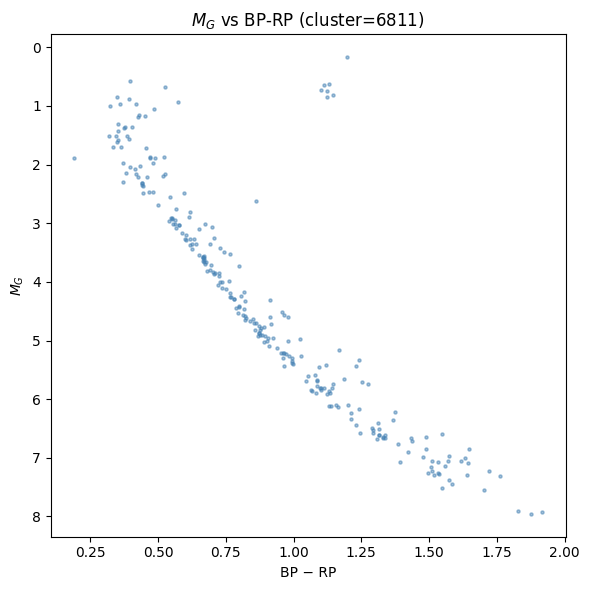

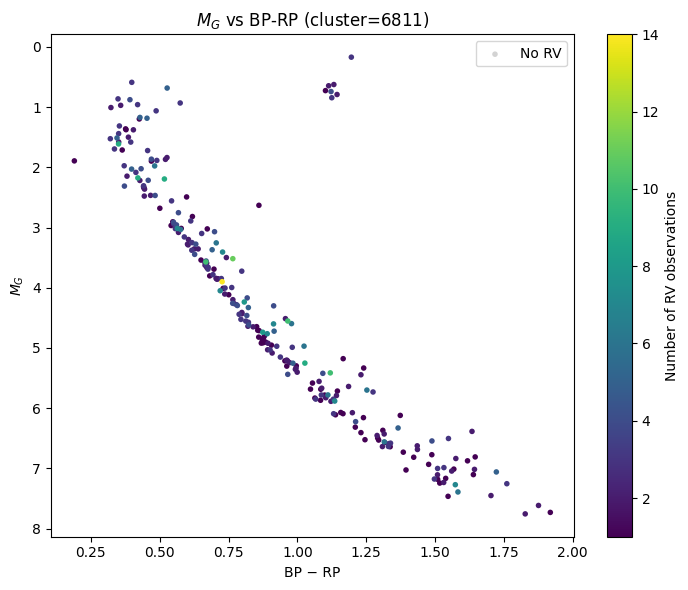


------------------------------------------------------------
h5 and fits matching
------------------------------------------------------------
Stars in h5 but not in fits:         44
Stars in h5 and in fits:           2672
Total unique h5 stars:             2716

------------------------------------------------------------
Membership
------------------------------------------------------------
Members in h5:                      260
Members in h5 and in fits:          260
Members in h5 not in fits:            0
Nonmembers in h5 not in fits:        44

------------------------------------------------------------
Nonmembers in h5 but not in fits for 6811
------------------------------------------------------------
    GAIAEDR3_ID     HDBscan_Cluster
------------------- ---------------
2080062080320070912            -2.0
2080063763947694976            -2.0
2080086716253556224            -2.0
2080088125006478208            -2.0
2080090255310324736            -2.0
2080091045585561472      

In [26]:
M_g_BPRP_h5(cluster="6811")
M_g_BPRP_h5_rv_counts(fits_path="rcat_ngc6811_v0.fits", cluster="6811")